# Tutorial 1: Preprocessing using DeepCAROM Data Module
This tutorial provides a complete overview of the DeepCAROM data processing module for handling both 1D and 2D simulation data for training end-to-end reduced order models (ROMs).


In [1]:
# Import and version
import deepcarom

print("DeepCAROM version:", deepcarom.__version__)

DeepCAROM version: 0.1.0


## Data Structures <a name="data-structures"></a>

DeepCAROM expects numpy simulation data in specific formats:

- **1D Field Data**: `(n_simulations, n_timesteps, state_dim)`
- **2D Image Data**: `(n_simulations, n_timesteps, channels, height, width)`
- **Controls**: `(n_simulations, n_timesteps, control_dim)`

### 1D Sample Data

In [11]:
import numpy as np
import matplotlib.pyplot as plt

n_simulations_1d = 10
n_timesteps_1d = 100
state_dim_1d = 64

# Create synthetic 1D Heat Diffusion data
states_1d = np.zeros((n_simulations_1d, n_timesteps_1d, state_dim_1d))
controls_1d = np.random.randn(n_simulations_1d, n_timesteps_1d, 2) # 2 control inputs

# Parameters for Heat Equation
alpha = 1.0  # Thermal diffusivity
dt = 0.1    # Time step
dx = 1.0     # Spatial step
r = alpha * dt / (dx**2) # Stability parameter (must be < 0.5 for explicit scheme)

print(f"Stability parameter r: {r:.4f} (should be < 0.5)")

for sim in range(n_simulations_1d):
    # Initial condition: Random smooth temperature profile
    x = np.linspace(0, 10, state_dim_1d)
    initial_temp = 20.0 + 80.0 * np.exp(-0.5 * (x - np.random.uniform(2, 8))**2)
    states_1d[sim, 0] = initial_temp
    
    # Heat equation simulation (Explicit Finite Difference)
    for t in range(1, n_timesteps_1d):
        u = states_1d[sim, t-1]
        
        # Diffusion: u_new = u + r * (u_left - 2u + u_right)
        diffusion = r * (u[:-2] - 2*u[1:-1] + u[2:])
        
        # Control influence (heating/cooling at specific locations)
        # Control 0 affects left side, Control 1 affects right side
        control_effect = np.zeros(state_dim_1d - 2)
        control_effect[10] += 0.5 * controls_1d[sim, t, 0] 
        control_effect[-10] += 0.5 * controls_1d[sim, t, 1]
        
        # Update field
        states_1d[sim, t, 1:-1] = u[1:-1] + diffusion + control_effect
        
        # Boundary conditions (Dirichlet: fixed temperature at ends)
        states_1d[sim, t, 0] = 20.0
        states_1d[sim, t, -1] = 20.0

print(f"1D States shape: {states_1d.shape}")
print(f"1D Controls shape: {controls_1d.shape}")
print(f"Temperature range: [{np.min(states_1d):.3f}, {np.max(states_1d):.3f}]")
print(f"Controls range: [{np.min(controls_1d):.3f}, {np.max(controls_1d):.3f}]")

Stability parameter r: 0.1000 (should be < 0.5)
1D States shape: (10, 100, 64)
1D Controls shape: (10, 100, 2)
Temperature range: [16.695, 99.993]
Controls range: [-3.596, 3.059]


### Visualization

Utility functions are provided for animating simulation results. The `animate_1Dsimulation` function creates GIF animations of 1D field data over time given either numpy or torch tensors in the shape `(n_timesteps, state_dim)`.

In [10]:
from deepcarom.utils import animate_1Dsimulation

animate_1Dsimulation(data=states_1d[2], save_path="./images/1D_simulation.gif", title="1D Heat Diffusion Simulation")

## Configuration <a name="configuration"></a>

The `DataConfig` class controls all aspects of data processing:

In [3]:
from deepcarom.data import DataConfig

config = DataConfig(
    # Data splitting
    train_split=0.6,
    val_split=0.2,
    test_split=0.2,
    
    # Sequence parameters
    lookback=10,        # Use 10 past time steps as input
    pred_horizon=5,     # Predict 5 future time steps
    stride=1,           # No skipping between sequences
    
    # Scaling
    scale_states=True,
    scale_controls=False,
    scale_states_collectively=True, # Scale all states together (one high-dimensional field)
    scale_controls_collectively=False, # Scale controls separately
    scaling_method="minmax",  # Scaling method: "minmax" or "standard"
    
    # Device
    device="cpu" # by default gpu if available
)

print("Configuration:")
print(f"  Lookback: {config.lookback}")
print(f"  Prediction Horizon: {config.pred_horizon}")
print(f"  Scaling: {config.scale_states}")

Configuration:
  Lookback: 10
  Prediction Horizon: 5
  Scaling: True


## Processing

The main workflow uses `DataPreprocessor.process_simulations()` which:
1. **Validates** input shapes and consistency
2. **Splits** data into train/val/test sets
3. **Scales** data across simulations
4. **Creates** input-target sequences
5. **Returns** both sequences (training) and simulations (evaluation)

In [4]:
from deepcarom.data import DataPreprocessor

# Initialize Data Preprocessor
processor = DataPreprocessor(config=config)
# Process the data
processed_data = processor.process_simulations(states=states_1d, controls=controls_1d)

Scaling states using:  minmax


## Data Processing Output Structure

The `process_simulations()` method returns a comprehensive dictionary containing both training sequences and preserved simulations for evaluation as torch tensors.

### Output Dictionary Structure

```python
processed_data = {
    'datasets': {
        'train': SequenceDataset,    # Training sequences
        'val': SequenceDataset,      # Validation sequences  
        'test': SequenceDataset      # Test sequences
    },
    'simulations': {
        'train': SimulationData,     # Full training simulations
        'val': SimulationData,       # Full validation simulations
        'test': SimulationData       # Full test simulations
    },
    'metadata': {
        'state_scaler': Scaler,      # Fitted state scaler
        'control_scaler': Scaler,    # Fitted control scaler
        'config': DataConfig         # Processing configuration
    }
}

In [5]:
print("Processed data keys:", list(processed_data.keys()))
print("\nDataset splits available:", list(processed_data['datasets'].keys()))
print("Simulation splits available:", list(processed_data['simulations'].keys()))
print("Metadata keys:", list(processed_data['metadata'].keys()))

Processed data keys: ['datasets', 'simulations', 'metadata']

Dataset splits available: ['train', 'val', 'test']
Simulation splits available: ['train', 'val', 'test']
Metadata keys: ['state_scaler', 'control_scaler', 'config']


### 1. Training Datasets (`datasets`)

The `datasets` contain `SequenceDataset` objects ready for PyTorch training, providing input-target sequences (scaled if configured) in the format:

- **Input States**: `(lookback, *state_dims)` - Past states used for initial condition
- **Input Controls**: `(lookback + pred_horizon - 1, control_dim)` - Control signals covering both the input and prediction periods  
- **Target States**: `(pred_horizon, *state_dims)` - Future states to predict

#### Sequence Length Justification

The control sequence length is designed to provide all necessary inputs for the entire prediction window:

- **For single-step prediction** (`pred_horizon = 1`): Controls shape = `(lookback, control_dim)`  
  (only the input period controls are needed)

- **For multi-step prediction** (`pred_horizon > 1`): Controls shape = `(lookback + pred_horizon - 1, control_dim)`  
  (includes both input period controls **and** future controls during prediction)

This ensures the model has access to all control inputs that influence the states throughout the prediction horizon.

In [6]:
# Examine training dataset
train_dataset = processed_data['datasets']['train']
print(f"Training dataset size: {len(train_dataset)} sequences")

# Get one training example
X, U, Y = train_dataset[0]

print(f"\nTraining sequence shapes:")
print(f"  Input states: {X.shape}")      # (lookback, state_dim)
print(f"  Input controls: {U.shape}")  # (lookback+pred_horizon-1, control_dim)
print(f"  Target states: {Y.shape}")    # (pred_horizon, state_dim)

Training dataset size: 516 sequences

Training sequence shapes:
  Input states: torch.Size([10, 64])
  Input controls: torch.Size([14, 2])
  Target states: torch.Size([5, 64])


### 2. Preserved Simulations (`simulations`)

The `simulations` contain `SimulationData` objects storing complete simulation trajectories for evaluation and visualization. Each `SimulationData` has:
- `states`: Original state data
- `controls`: Original control data  
- `states_scaled`: Scaled state data (if scaling applied)
- `controls_scaled`: Scaled control data (if scaling applied)

In [7]:
# Examine test simulations
test_simulation = processed_data['simulations']['test'][0] # First test simulation
print(f"Test simulation shape: {test_simulation.shape}")

print(f"\nSimulationData attributes:")
print(f"  Original states shape: {test_simulation.states.shape}")
print(f"  Scaled states shape: {test_simulation.states_scaled.shape}")
print(f"  Original controls shape: {test_simulation.controls.shape}")
print(f"  Scaled controls shape: {test_simulation.controls_scaled.shape}")

# Show scaling effect
print(f"\nScaling example (first simulation, first timestep):")
print(f"  Original range of current simulation: [{test_simulation.states.amin():.3f}, {test_simulation.states.amax():.3f}]")
print(f"  Scaled range of current simulation: [{test_simulation.states_scaled.amin():.3f}, {test_simulation.states_scaled.amax():.3f}]")

Test simulation shape: torch.Size([1, 100, 64])

SimulationData attributes:
  Original states shape: torch.Size([1, 100, 64])
  Scaled states shape: torch.Size([1, 100, 64])
  Original controls shape: torch.Size([1, 100, 2])
  Scaled controls shape: torch.Size([1, 100, 2])

Scaling example (first simulation, first timestep):
  Original range of current simulation: [17.680, 99.963]
  Scaled range of current simulation: [0.014, 1.000]


### 3. Processing Metadata (`metadata`)

The `metadata` contains information about the processing pipeline:
- `state_scaler`: Fitted scaler for state data (enables inverse transformation)
- `control_scaler`: Fitted scaler for control data  
- `config`: The `DataConfig` used for processing

In [8]:
# Examine metadata
metadata = processed_data['metadata']
print("Metadata contents:")
print(f"  State scaler type: {type(metadata['state_scaler']).__name__}")
print(f"  Control scaler type: {type(metadata['control_scaler']).__name__}")
print(f"  Config lookback: {metadata['config'].lookback}")
print(f"  Config pred_horizon: {metadata['config'].pred_horizon}")

# Demonstrate inverse scaling
if metadata['state_scaler'] is not None:
    test_scaled = test_simulation.states_scaled.numpy()
    test_original = test_simulation.states.numpy()
    test_inverted = processor.inverse_scale_states(test_scaled)
    
    scaling_error = np.max(np.abs(test_original - test_inverted))
    print(f"\nScaling inversion test:")
    print(f"  Max inversion error: {scaling_error:.2e}")

Metadata contents:
  State scaler type: MinMaxScaler
  Control scaler type: NoneType
  Config lookback: 10
  Config pred_horizon: 5

Scaling inversion test:
  Max inversion error: 6.19e-06


### 2D sample Data

We demonstrate the usability of the `DataPreprocessor` on a 2D example consiting of a ball moving within a box. The simulation database can be downloaded from [here](https://ruhr-uni-bochum.sciebo.de/s/c79mWK3NityATLT). It consists of a single long simulation with 5000 timesteps.

Loaded simulation shape: (1, 5000, 1, 64, 64)
Loaded controls shape: (1, 5000, 2)


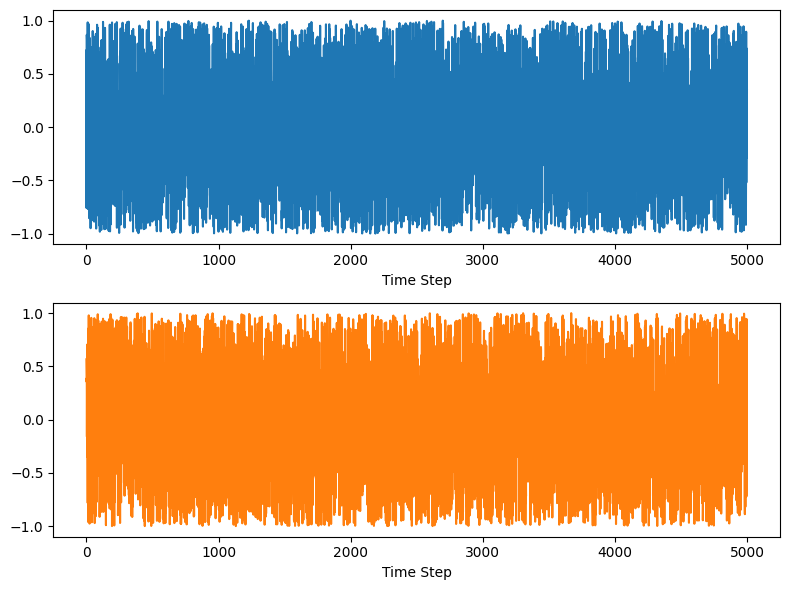

In [46]:
import pickle

with open("./data/Ball-in-Box.pkl", "rb") as f:
    data = pickle.load(f)

states_2d = data['simulation']
controls_2d = data['controls']
print(f"Loaded simulation shape: {states_2d.shape}")
print(f"Loaded controls shape: {controls_2d.shape}")

# plot the control signals
fig, axs = plt.subplots(2,1,figsize=(8, 6))
axs[0].plot(controls_2d[0,:,0]) 
axs[0].set_xlabel('Time Step')  
axs[1].plot(controls_2d[0,:,1], color='C1')
axs[1].set_xlabel('Time Step')  
plt.tight_layout()
plt.show() 


The `animate_2Dsimulation` function creates GIF animations of a 2D field (channel) data over time given either numpy or torch tensors in the shape `(n_timesteps, state_dim1, state_dim2)`. 

In [30]:
from deepcarom.utils import animate_2Dsimulation

# Visualize the first 150 timesteps
animate_2Dsimulation(data=states_2d[0][:150], save_path="./images/2D_simulation.gif", title="Ball-in-Box Simulation", channel=0, show_colorbar=True, cmap="gray")

Animation saved to: ./images/2D_simulation.gif


Similar to the 1D case, the `DataConfig` class controls all aspects of data processing:

In [31]:
config2 = DataConfig(
    # Data splitting
    train_split=0.2,
    val_split=0.3,
    test_split=0.5,
    
    # Sequence parameters
    lookback=5,        # Use 5 past time steps as input
    pred_horizon=3,     # Predict 3 future time steps
    stride=1,           # No skipping between sequences
    
    # Scaling
    scale_states=True,
    scale_controls=True,
    scale_states_collectively=True, # Scale all states together (one high-dimensional field)
    scale_controls_collectively=False, # Scale controls separately
    scaling_method="minmax",  # Scaling method: "minmax" or "standard"
    
    # Device
    device="cpu" # by default gpu if available
)

print("Configuration:")
print(f"  Lookback: {config2.lookback}")
print(f"  Prediction Horizon: {config2.pred_horizon}")
print(f"  Scaling: {config2.scale_states}")

Configuration:
  Lookback: 5
  Prediction Horizon: 3
  Scaling: True


`DataPreprocessor.process_simulations()` automatically detects the data structure and processes it using the same unified interface, regardless of being 1D or 2D. The processor handles shape detection, collective scaling, and sequence generation transparently. 

In case of a single simulation, the `datasets` are generated with respect to the total number of time step only.

In [34]:
# Initialize Data Preprocessor
processor = DataPreprocessor(config=config2)
# Process the data
processed_data_2D = processor.process_simulations(states=states_2d, controls=controls_2d)

# Examine training dataset
train_dataset = processed_data_2D['datasets']['train']
print(f"Training dataset size: {len(train_dataset)} sequences")

# Get one training example
X, U, Y = train_dataset[0]

print(f"\nTraining sequence shapes:")
print(f"  Input states: {X.shape}")      # (lookback, state_dim)
print(f"  Input controls: {U.shape}")  # (lookback+pred_horizon-1, control_dim)
print(f"  Target states: {Y.shape}")    # (pred_horizon, state_dim)

Single simulation detected. Splitting along time axis: Train=1000, Val=1500, Test=2500 steps.
Scaling states using:  minmax
Scaling controls using:  minmax
Training dataset size: 993 sequences

Training sequence shapes:
  Input states: torch.Size([5, 1, 64, 64])
  Input controls: torch.Size([7, 2])
  Target states: torch.Size([3, 1, 64, 64])


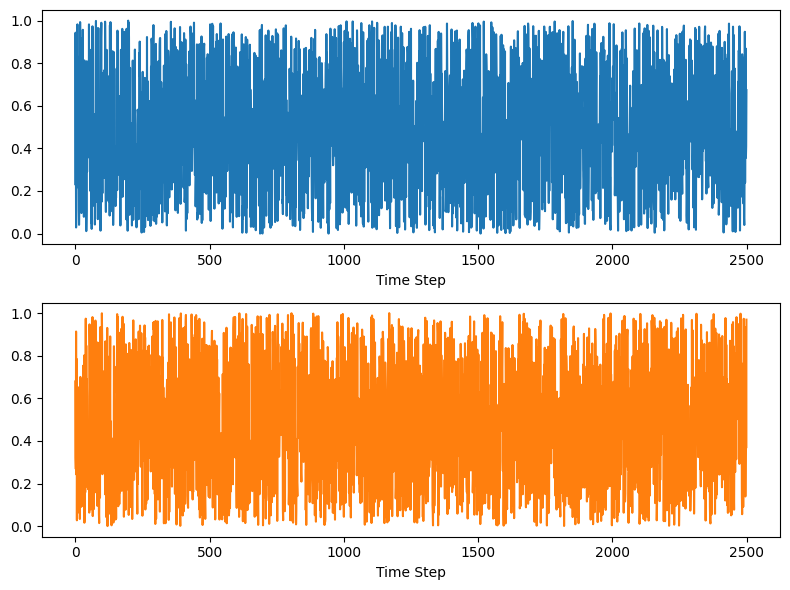

Animation saved to: ./images/2D_simulation_scaled.gif


In [47]:
# get the test simulation
test_simulation = processed_data_2D['simulations']['test'][0]

# plot the scaled control signals
controls_scaled = test_simulation.controls_scaled
fig, axs = plt.subplots(2,1,figsize=(8, 6))
axs[0].plot(controls_scaled[0,:,0]) 
axs[0].set_xlabel('Time Step')  
axs[1].plot(controls_scaled[0,:,1], color='C1')
axs[1].set_xlabel('Time Step')  
plt.tight_layout()
plt.show()

# Visualize the scaled test simulation
animate_2Dsimulation(data=test_simulation.states_scaled[0][:150], save_path="./images/2D_simulation_scaled.gif", title="Scaled Ball-in-Box Simulation", channel=0, show_colorbar=True, cmap="gray")